# Adım 9 — Karar eşiği ve çalışma noktası

**Neden bu notebook var.** Şu ana kadar her rakam `predict()`'in **varsayılan** kararıyla
üretildi: çok sınıflıda en yüksek olasılıklı sınıf, binary türevde "normal değilse atak". Bu
tek bir **çalışma noktasıdır**, üstelik keyfî olanıdır.

Bir saldırı tespit sisteminde yanlış alarmın maliyeti ile kaçırmanın maliyeti **aynı değildir**.
Klinik bir ağda operatörü günde yüzlerce yanlış alarmla boğan bir sistem, teknik olarak yüksek
recall'a sahip olsa bile kullanılamaz. Bu yüzden asıl soru "skor kaç" değil:

> **Kabul edebileceğim yanlış alarm bütçesinde, saldırıyı hangi şiddete kadar görebiliyorum?**

Bu notebook üç şey yapıyor:
1. Kararı bir **skora** çevirip precision–recall eğrisini çıkarıyor (varsayılan eşik yerine bütün takas)
2. Varsayılan eşiğin bu eğrinin **neresinde** durduğunu işaretliyor
3. Şiddet eğrisini birkaç yanlış-alarm bütçesinde yeniden çiziyor — yani "çöküş noktası"nın
   bütçeye göre nasıl kaydığını gösteriyor

**İki görev ayrı ayrı ele alınıyor**, çünkü ikisi farklı soru soruyor (Adım 8):

| görev | negatif sınıf | pozitif sınıf |
|---|---|---|
| **A — klasik** | `normal` (relay yok) | her saldırı |
| **B — relay-göreli** | zararsız relay (grey `p=0`) | kötü niyetli relay (grey `p>0`) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- Dondurulmus release v1 uzerinde calisiyoruz (provenance: MANIFEST_v1.json) ---
def _find(*cands):
    p = next((Path(c) for c in cands if Path(c).exists()), None)
    assert p is not None, f"bulunamadi: {cands}"
    return p

REL = _find("my-work/day9-20072026-release/release", "../day9-20072026-release/release")
tr = pd.read_csv(REL / "dataset_v1.csv")
pr = pd.read_csv(REL / "probes_v1.csv")

# Feature listesi burada TANIMLANMIYOR, my-work/detector_schema.py'den geliyor.
# Kopyalanmis listeler birbirinden ayrilmisti: 02-07 bu ozellik eklenmeden once yazildi
# (12 girdi), 08-10 sonra (13), yayimlanan model 13. check_against_release() semayi
# yayimlanan manifest'e karsi dogruluyor -- buradaki sayilar teslim edilmis modeli
# anlatmiyorsa hucre patlar.
import sys
for _p in ("my-work", "..", "../.."):
    if (Path(_p)/"detector_schema.py").exists(): sys.path.insert(0, _p); break
from detector_schema import FEATURES, build_X, check_against_release
_rel = check_against_release()
print(f"sema surum {_rel['version']} ile uyusuyor ({len(_rel['model']['features'])} girdi)")

prep = build_X   # tek tanim: detector_schema.build_X

# Sub-10 DoS egitimde yok (Adim 5) -- release ile ayni kural.
tr = tr[~((tr.scenario == "dos") & (tr.intensity < 10))].reset_index(drop=True)
RF = lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0)
CV = lambda: StratifiedGroupKFold(5, shuffle=True, random_state=0)
print(f"egitim {len(tr)} kosu | prob {len(pr)} kosu")

sema surum v1.1 ile uyusuyor (13 girdi)
egitim 255 kosu | prob 340 kosu


## 1. Kararı skora çevirmek

`predict()` bir etiket verir; eşik ayarı için **olasılık** gerekiyor. Her iki görevde de skorlar
`predict_proba` ile ve **config-grupli OOF** olarak üretiliyor — yani her koşunun skoru, o
koşunun konfigürasyonunu hiç görmemiş bir modelden geliyor. Bu şart: eğitim verisinden alınan
olasılıklar aşırı güvenli çıkar ve eşik seçimini yanıltır.

**Görev A'da atak skoru = 1 − P(normal).** Hangi saldırı tipi olduğu burada önemli değil, tespit
edilip edilmediği önemli.

In [2]:
# --- Gorev A: normal vs atak ---
groups_a = tr.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in {"normal", "blackhole"}
                              else f"{r.scenario}_i{r.intensity}", axis=1)
proba_a = cross_val_predict(RF(), prep(tr), tr.label_class, cv=CV(), groups=groups_a,
                            method="predict_proba")
classes_a = np.unique(tr.label_class)
score_a = 1.0 - proba_a[:, list(classes_a).index("normal")]   # "atak" skoru
ytrue_a = (tr.label_class != "normal").astype(int).to_numpy()

# --- Gorev B: zararsiz relay vs kotu niyetli relay, iki konumda (Adim 8 kurulumu) ---
ARMS_SRC = {
    "STA8 (31.6 m)": (pr[pr.scenario == "relay"], tr[tr.scenario == "greyhole"]),
    "STA5 (10.0 m)": (pr[(pr.scenario == "relaypos") & (pr.intensity == 5)],
                      pr[pr.scenario == "greypos"]),
}
ARMS = {}
for tag, (benign, mal) in ARMS_SRC.items():
    d = pd.concat([benign.assign(y="benign"), mal.assign(y="malicious")], ignore_index=True)
    g = d.apply(lambda r: f"benign_run{r.run}" if r.y == "benign" else f"grey_i{r.intensity}",
                axis=1)
    pb = cross_val_predict(RF(), prep(d), d.y, cv=CV(), groups=g, method="predict_proba")
    d["score"] = pb[:, list(np.unique(d.y)).index("malicious")]
    ARMS[tag] = d
    print(f"{tag}: {len(d)} kosu ({(d.y=='benign').sum()} zararsiz)")

STA8 (31.6 m): 150 kosu (40 zararsiz)


STA5 (10.0 m): 150 kosu (40 zararsiz)


## 2. Varsayılan eşik nerede duruyor?

Varsayılan karar (argmax) tek bir noktadır. Aşağıdaki tablo onu, aynı skorlardan seçilebilecek
**diğer** noktalarla yan yana koyuyor.

**Yanlış alarm bütçesi nasıl uygulanıyor:** negatif sınıfın skorlarının uygun yüzdeliği eşik
olarak alınıyor. Örneğin %10 bütçe = zararsız koşuların skorlarının 90. yüzdeliği.

> **Çözünürlük sınırı — dürüstlük notu.** Görev B'de negatif sınıf 40 koşu, yani yanlış alarm
> ancak **1/40 = 0.025** adımlarla ölçülebilir. "%1 bütçe" gibi bir hedef bu veriyle
> **çözülemez**; aşağıdaki bütçeler bu tanenin katları seçildi. Görev A'da negatif sınıf yalnız
> 40 `normal` koşusu olduğu için aynı sınır geçerli.

In [3]:
def operating_points(score, ytrue, budgets, default_pred):
    """Verilen yanlis-alarm butcelerinde esik, tespit orani ve gerceklesen FA.

    `default_pred`: modelin ARGMAX karari (0/1). Bunu skordan turetmiyoruz, cunku cok
    sinifli bir modelde `1 - P(normal) >= 0.5` ile argmax AYNI SEY DEGIL: P(normal)=0.45
    ve kalan olasilik dort sinifa dagilmissa argmax 'normal' der, esik 'atak' der. Ikisini
    karistirmak Adim 5'in bildirdigi yanlis alarmdan (0.125) farkli bir sayi uretiyordu (0.225).
    """
    neg, pos = score[ytrue == 0], score[ytrue == 1]
    rows = [{"nokta": "varsayilan (argmax)", "esik": np.nan,
             "yanlis_alarm": default_pred[ytrue == 0].mean(),
             "tespit": default_pred[ytrue == 1].mean()}]
    for b in budgets:
        thr = np.quantile(neg, 1.0 - b)          # negatiflerin (1-b) yuzdeligi
        rows.append({"nokta": f"FA butcesi <= {b:.0%}", "esik": thr,
                     "yanlis_alarm": (neg >= thr).mean(), "tespit": (pos >= thr).mean()})
    return pd.DataFrame(rows)

BUDGETS = [0.05, 0.10, 0.25]

# Argmax karari AYRI hesaplaniyor (yukaridaki docstring): cok sinifli modelde skor esigi
# ile argmax farkli kararlar verir. Adim 5 ile ayni sayiyi uretmesi beklenir (FA 0.125).
label_a = cross_val_predict(RF(), prep(tr), tr.label_class, cv=CV(), groups=groups_a)
default_a = (label_a != "normal").astype(int)

print("=== GOREV A — normal vs atak ===")
print(operating_points(score_a, ytrue_a, BUDGETS, default_a).round(3).to_string(index=False))
print(f"\n  average precision (AP): {average_precision_score(ytrue_a, score_a):.3f}")

for tag, d in ARMS.items():
    yt = (d.y == "malicious").astype(int).to_numpy()
    # Iki sinifli gorevde argmax == 0.5 esigi, ama tutarlilik icin ayni yoldan hesapliyoruz.
    default_b = (d.score.to_numpy() >= 0.5).astype(int)
    print(f"\n=== GOREV B — {tag} ===")
    print(operating_points(d.score.to_numpy(), yt, BUDGETS, default_b).round(3).to_string(index=False))
    print(f"  AP: {average_precision_score(yt, d.score):.3f}")

=== GOREV A — normal vs atak ===
              nokta  esik  yanlis_alarm  tespit
varsayilan (argmax)   NaN          0.15   0.949
   FA butcesi <= 5% 0.731          0.05   0.893
  FA butcesi <= 10% 0.618          0.10   0.940
  FA butcesi <= 25% 0.491          0.25   0.953

  average precision (AP): 0.993

=== GOREV B — STA8 (31.6 m) ===
              nokta  esik  yanlis_alarm  tespit
varsayilan (argmax)   NaN          0.35   0.909
   FA butcesi <= 5% 0.860          0.05   0.555
  FA butcesi <= 10% 0.754          0.10   0.691
  FA butcesi <= 25% 0.612          0.25   0.827
  AP: 0.956

=== GOREV B — STA5 (10.0 m) ===
              nokta  esik  yanlis_alarm  tespit
varsayilan (argmax)   NaN         0.225   0.900
   FA butcesi <= 5% 0.641         0.050   0.845
  FA butcesi <= 10% 0.627         0.100   0.855
  FA butcesi <= 25% 0.435         0.250   0.927
  AP: 0.980


## 3. Asıl soru — bütçe, çöküş noktasını nereye taşıyor?

Adım 8 tek bir çalışma noktasında çöküşün `p = 0.1`'de olduğunu buldu. Ama o nokta varsayılan
eşikti ve **%22.5–35 yanlış alarma** karşılık geliyordu — operasyonel olarak kabul edilemez.

Aşağıdaki panel şiddet eğrisini birkaç bütçede yeniden çiziyor. Okunacak şey: bütçe daraldıkça
saldırının görünür olması için **ne kadar daha agresif** olması gerekiyor.

In [4]:
def intensity_at_budget(d, budgets):
    """Her butcede, yogunluk basina tespit orani."""
    neg = d.loc[d.y == "benign", "score"].to_numpy()
    mal = d[d.y == "malicious"]
    out = {}
    for b in budgets:
        thr = np.quantile(neg, 1.0 - b)
        out[b] = mal.groupby("intensity").score.apply(lambda s: (s >= thr).mean())
    return pd.DataFrame(out)

for tag, d in ARMS.items():
    print(f"\n=== {tag} — yogunluga gore tespit, butceye gore ===")
    t = intensity_at_budget(d, BUDGETS)
    t.columns = [f"FA<={b:.0%}" for b in t.columns]
    print(t.round(2).to_string())


=== STA8 (31.6 m) — yogunluga gore tespit, butceye gore ===
           FA<=5%  FA<=10%  FA<=25%
intensity                          
0.02          0.0      0.0      0.2
0.05          0.0      0.1      0.3
0.10          0.1      0.1      0.7
0.20          0.3      0.6      0.9
0.30          0.1      0.8      1.0
0.40          0.7      1.0      1.0
0.50          1.0      1.0      1.0
0.60          1.0      1.0      1.0
0.70          0.9      1.0      1.0
0.80          1.0      1.0      1.0
0.90          1.0      1.0      1.0

=== STA5 (10.0 m) — yogunluga gore tespit, butceye gore ===
           FA<=5%  FA<=10%  FA<=25%
intensity                          
0.02          0.1      0.1      0.4
0.05          0.4      0.5      0.8
0.10          0.8      0.8      1.0
0.20          1.0      1.0      1.0
0.30          1.0      1.0      1.0
0.40          1.0      1.0      1.0
0.50          1.0      1.0      1.0
0.60          1.0      1.0      1.0
0.70          1.0      1.0      1.0
0.80          

## 4. Figür

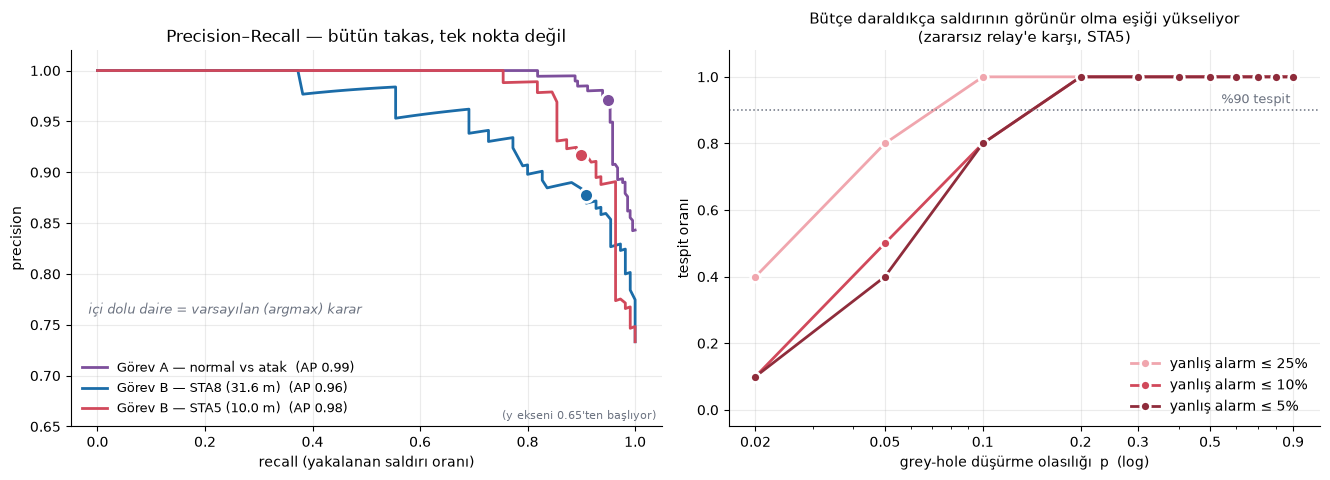

In [5]:
# --- Paletler ---
# Kategorik (3 seri): dataviz validator 5/5 PASS, en kotu CVD dE 12.4, normal gorus 18.7
C_A    = "#7d4f9c"   # mor    = Gorev A (normal vs atak)
C_STA8 = "#1b6ca8"   # mavi   = Gorev B, STA8
C_STA5 = "#d1495b"   # kirmizi= Gorev B, STA5
# Sirali (butceler ordinal, kategorik degil): tek hue, acik -> koyu
RAMP = ["#f0a6ae", "#d1495b", "#8f2c3b"]
C_INK = "#6b7280"

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))

# ================= Panel 1: precision-recall =================
ax = axes[0]
SERIES = [("Görev A — normal vs atak", score_a, ytrue_a, default_a, C_A)]
for tag, col in (("STA8 (31.6 m)", C_STA8), ("STA5 (10.0 m)", C_STA5)):
    d = ARMS[tag]
    SERIES.append((f"Görev B — {tag}", d.score.to_numpy(),
                   (d.y == "malicious").astype(int).to_numpy(),
                   (d.score.to_numpy() >= 0.5).astype(int), col))

for label, sc, yt, dflt, col in SERIES:
    p, r, _ = precision_recall_curve(yt, sc)
    ap = average_precision_score(yt, sc)
    ax.plot(r, p, "-", color=col, lw=2, label=f"{label}  (AP {ap:.2f})")
    # Varsayilan (ARGMAX) kararin bu egri uzerindeki yeri -- skor esiginden turetilmiyor,
    # cunku cok sinifli gorevde ikisi farkli noktalar (yukariya bkz).
    if dflt.sum():
        ax.plot(yt[dflt == 1].sum() / yt.sum(), yt[dflt == 1].sum() / dflt.sum(),
                "o", color=col, ms=10, markeredgecolor="white", markeredgewidth=2, zorder=5)

ax.annotate("içi dolu daire = varsayılan (argmax) karar", xy=(0.03, 0.30),
            xycoords="axes fraction", color=C_INK, fontsize=9, style="italic")
ax.set_xlabel("recall (yakalanan saldırı oranı)"); ax.set_ylabel("precision")
ax.set_title("Precision–Recall — bütün takas, tek nokta değil")
# Egrilerin tamami 0.7 uzerinde; 0'dan baslatmak panelin yarisini bos birakip
# aralarindaki farki okunamaz kiliyordu. Eksen kirpildi, taban etiketle belirtiliyor.
ax.set_ylim(0.65, 1.02)
ax.annotate("(y ekseni 0.65'ten başlıyor)", xy=(0.99, 0.02), xycoords="axes fraction",
            ha="right", color=C_INK, fontsize=8)
ax.grid(alpha=0.25); ax.legend(loc="lower left", frameon=False, fontsize=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)

# ================= Panel 2: butceye gore siddet egrisi (STA5) =================
ax = axes[1]
d5 = ARMS["STA5 (10.0 m)"]
t5 = intensity_at_budget(d5, BUDGETS)
XT = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.9]
for (b, col) in zip(BUDGETS[::-1], RAMP):          # genis butce acik, dar butce koyu
    ys = t5[b]
    ax.plot(ys.index, ys.values, "o-", color=col, lw=2, ms=7,
            markeredgecolor="white", markeredgewidth=1.8, label=f"yanlış alarm ≤ {b:.0%}")
ax.axhline(0.9, color=C_INK, lw=1.1, ls=":")
ax.annotate("%90 tespit", xy=(0.9, 0.9), xytext=(-2, 5), textcoords="offset points",
            ha="right", color=C_INK, fontsize=9)
ax.set_xscale("log"); ax.set_xticks(XT); ax.set_xticklabels([str(t) for t in XT])
ax.set_ylim(-0.05, 1.08)
ax.set_xlabel("grey-hole düşürme olasılığı  p  (log)")
ax.set_ylabel("tespit oranı")
ax.set_title("Bütçe daraldıkça saldırının görünür olma eşiği yükseliyor\n(zararsız relay'e karşı, STA5)",
             fontsize=11)
ax.grid(alpha=0.25); ax.legend(loc="lower right", frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.tight_layout()
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS / "N-esik-ayari.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Okuma

Bu notebook bir **skor iyileştirmesi değil**; aynı modelin farklı okumaları. Model değişmedi,
sorduğumuz soru değişti: "ne kadar iyi" yerine "hangi bütçede ne kadar iyi".

Rapora girecek ifade, sabit bir F1 değil bir **takas cümlesi** olmalı:

> Detektör varsayılan eşiğinde grey-hole'ü `p ≥ 0.1`'den itibaren yakalıyor, ancak bu nokta
> zararsız bir aracıya karşı %22.5 yanlış alarma karşılık geliyor. Operasyonel olarak
> savunulabilir bir bütçeye çekildiğinde, saldırının görünür olması için gereken düşürme oranı
> yükseliyor.

**Sınır (tekrar):** negatif sınıf 40 koşu → yanlış alarm çözünürlüğü 0.025. Bütçe rakamları bu
taneden ince okunmamalı; eğrilerin şekli tek tek noktalardan daha güvenilirdir.